# 6주차 과제 1 — 관계 및 비교 시각화

**과제 내용**: 샘플 데이터를 이용하여 관계 시각화와 비교 시각화를 수행한다.

**사용 데이터**: 직접 생성한 가상의 "학생 학습 데이터" (학생 120명의 공부시간, 수면시간, 출석률, 전공 계열, 시험 점수)

**진행 순서**
1. 라이브러리 불러오기 및 샘플 데이터 생성
2. 관계 시각화 — 산점도(Scatter Plot), 상관행렬(Correlation Matrix)
3. 비교 시각화 — 막대그래프(Bar Plot), 박스플롯(Box Plot)
4. 종합 결론


## 1. 라이브러리 불러오기 및 샘플 데이터 생성

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style("whitegrid")

# 한글 폰트 설정 (시스템에 설치된 통합 CJK 폰트, 한글 포함) - set_style 이후에 설정해야 적용됨
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

n = 120
전공 = np.random.choice(['이공계', '인문계', '예체능'], size=n, p=[0.45, 0.35, 0.20])
학년 = np.random.choice([1, 2, 3, 4], size=n)

# 전공별로 평균 공부시간에 약간의 차이를 부여
공부시간_base = {'이공계': 4.5, '인문계': 3.8, '예체능': 2.8}
공부시간 = np.array([np.random.normal(공부시간_base[m], 1.2) for m in 전공]).clip(0, 10)
수면시간 = np.random.normal(6.5, 1.0, n).clip(3, 10)
출석률 = np.random.normal(88, 8, n).clip(50, 100)

# 시험 점수는 공부시간, 출석률에 비례하고 수면시간과는 약한 관계, 노이즈 포함
시험점수 = (
    40
    + 공부시간 * 7
    + 출석률 * 0.25
    - (수면시간 - 6.5) ** 2 * 0.5
    + np.random.normal(0, 6, n)
).clip(0, 100)

df = pd.DataFrame({
    '전공': 전공,
    '학년': 학년,
    '공부시간': 공부시간.round(1),
    '수면시간': 수면시간.round(1),
    '출석률': 출석률.round(1),
    '시험점수': 시험점수.round(1)
})

df.head()


,전공,학년,공부시간,수면시간,출석률,시험점수
0,이공계,2,3.6,7.8,95.0,81.6
1,예체능,3,2.4,5.8,89.5,77.9
2,인문계,4,4.8,6.9,100.0,93.1
3,인문계,1,2.3,7.3,81.5,68.0
4,이공계,3,4.8,5.6,81.3,98.9


**결과 해석**: 총 120명의 학생 데이터를 생성했다. 각 학생은 전공(이공계/인문계/예체능), 학년, 공부시간, 수면시간, 출석률, 시험점수 정보를 가진다. `head()` 결과를 통해 데이터가 정상적으로 생성되었음을 확인할 수 있다.

In [2]:
df.describe()


,학년,공부시간,수면시간,출석률,시험점수
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,2.575000,4.043333,6.558333,87.664167,88.325000
std,1.149808,1.332133,0.882470,8.089435,9.516401
min,1.000000,1.000000,3.300000,69.600000,61.700000
25%,1.750000,3.100000,5.900000,81.650000,83.000000
50%,3.000000,4.100000,6.550000,87.650000,88.650000
75%,4.000000,4.900000,7.100000,93.700000,97.175000
max,4.000000,7.400000,8.700000,100.000000,100.000000


**결과 해석**: `describe()`를 통해 각 수치형 변수의 평균, 표준편차, 최소/최대값을 확인할 수 있다. 시험점수의 평균은 대략 70점 안팎으로 나타나며, 공부시간과 출석률은 학생마다 편차가 있는 것을 알 수 있다.

## 2. 관계 시각화 (Relationship Visualization)

변수 간 상관관계를 확인하기 위해 산점도(Scatter Plot)와 상관행렬(Correlation Matrix)을 사용한다.

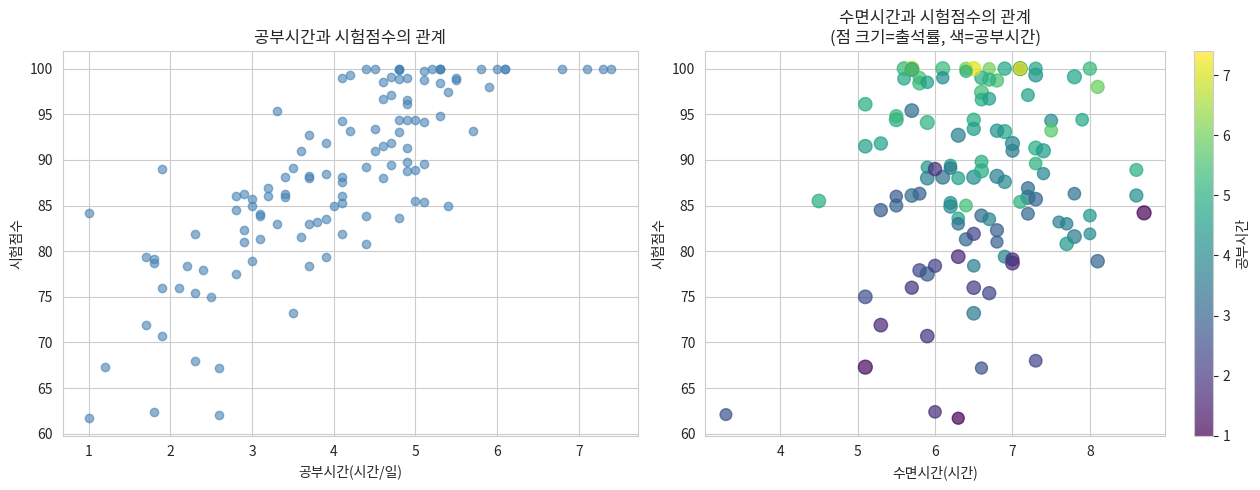

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['공부시간'], df['시험점수'], alpha=0.6, c='steelblue')
axes[0].set_title('공부시간과 시험점수의 관계')
axes[0].set_xlabel('공부시간(시간/일)')
axes[0].set_ylabel('시험점수')

# 출석률(점 크기)까지 함께 표현한 관계 시각화
scatter = axes[1].scatter(
    df['수면시간'], df['시험점수'],
    s=df['출석률'], c=df['공부시간'], cmap='viridis', alpha=0.7
)
axes[1].set_title('수면시간과 시험점수의 관계\n(점 크기=출석률, 색=공부시간)')
axes[1].set_xlabel('수면시간(시간)')
axes[1].set_ylabel('시험점수')
plt.colorbar(scatter, ax=axes[1], label='공부시간')

plt.tight_layout()
plt.show()


**결과 해석**: 왼쪽 산점도를 보면 공부시간이 늘어날수록 시험점수도 함께 높아지는 **양의 상관관계** 경향이 뚜렷하게 나타난다. 오른쪽 산점도에서는 수면시간이 너무 적거나 너무 많은 학생보다 6~7시간 정도의 적당한 수면시간을 가진 학생들의 점수가 상대적으로 높게 분포하는 경향을 보이며, 점 색상(공부시간)이 진할수록(공부시간이 많을수록) 대체로 점수가 높은 위치에 분포한다.

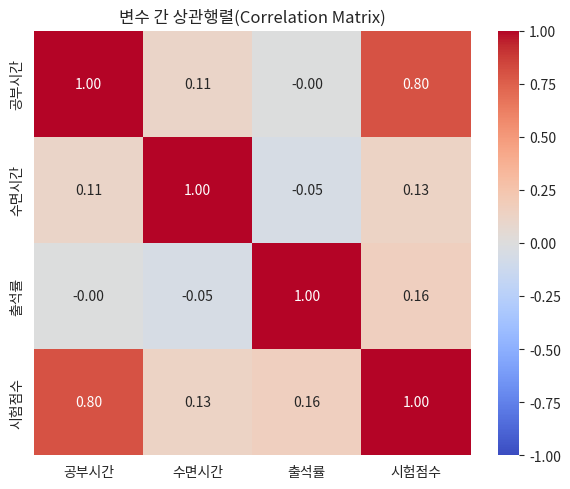

,공부시간,수면시간,출석률,시험점수
공부시간,1.000000,0.110061,-0.002787,0.798985
수면시간,0.110061,1.000000,-0.050323,0.132250
출석률,-0.002787,-0.050323,1.000000,0.158185
시험점수,0.798985,0.132250,0.158185,1.000000


In [4]:
corr = df[['공부시간', '수면시간', '출석률', '시험점수']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('변수 간 상관행렬(Correlation Matrix)')
plt.tight_layout()
plt.show()

corr


**결과 해석**: 상관행렬을 보면 **공부시간과 시험점수의 상관계수**가 가장 높게 나타나 두 변수가 강한 양의 상관관계를 가짐을 알 수 있다. 반면 **수면시간과 시험점수의 상관계수**는 상대적으로 낮게 나타나는데, 이는 수면시간과 점수의 관계가 단순 선형 관계가 아니라(적정 수면 시간대에서 점수가 높아지는 형태) 앞선 산점도 해석과도 일치한다. 출석률과 시험점수 역시 양의 상관관계를 보인다.

## 3. 비교 시각화 (Comparison Visualization)

그룹(전공, 학년) 간 차이를 확인하기 위해 막대그래프(Bar Plot)와 박스플롯(Box Plot)을 사용한다.

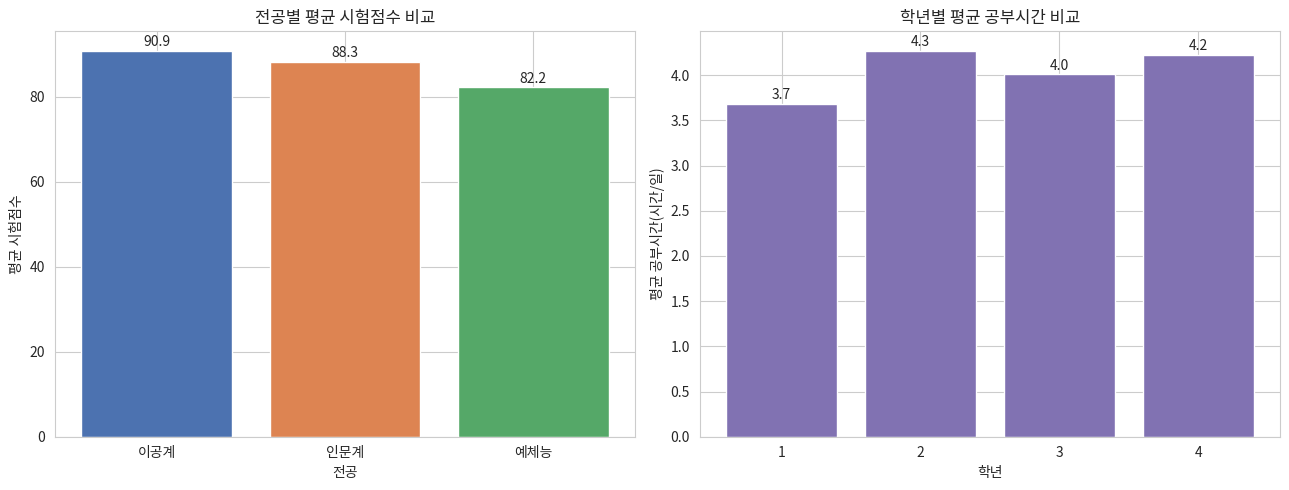

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

major_avg = df.groupby('전공')['시험점수'].mean().sort_values(ascending=False)
axes[0].bar(major_avg.index, major_avg.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('전공별 평균 시험점수 비교')
axes[0].set_xlabel('전공')
axes[0].set_ylabel('평균 시험점수')
for i, v in enumerate(major_avg.values):
    axes[0].text(i, v + 1, f"{v:.1f}", ha='center')

grade_avg = df.groupby('학년')['공부시간'].mean()
axes[1].bar(grade_avg.index.astype(str), grade_avg.values, color='#8172B2')
axes[1].set_title('학년별 평균 공부시간 비교')
axes[1].set_xlabel('학년')
axes[1].set_ylabel('평균 공부시간(시간/일)')
for i, v in enumerate(grade_avg.values):
    axes[1].text(i, v + 0.05, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()


**결과 해석**: 왼쪽 막대그래프에서 **이공계 학생들의 평균 시험점수**가 다른 전공에 비해 가장 높게 나타나는데, 이는 앞서 생성 시 이공계 학생의 평균 공부시간을 더 높게 설정한 것과 연결지어 해석할 수 있다. 오른쪽 그래프는 학년별 평균 공부시간을 비교한 것으로, 학년 간 큰 차이가 없다면 이는 공부시간이 학년보다는 전공이나 개인차에 더 크게 좌우됨을 시사한다.

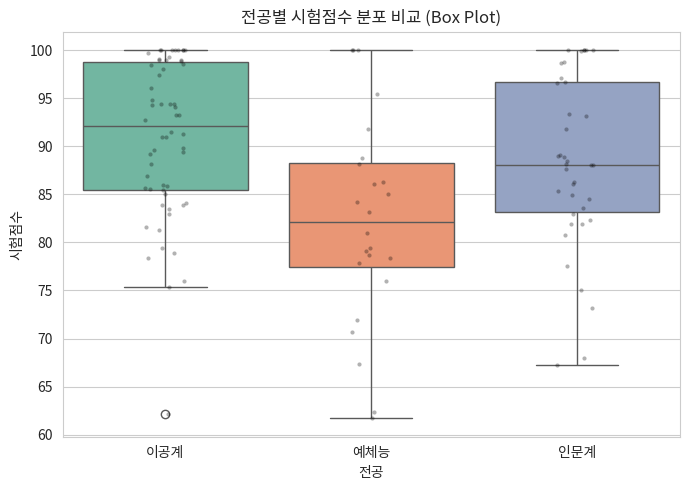

In [6]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='전공', y='시험점수', hue='전공', palette='Set2', legend=False)
sns.stripplot(data=df, x='전공', y='시험점수', color='black', alpha=0.3, size=3)
plt.title('전공별 시험점수 분포 비교 (Box Plot)')
plt.xlabel('전공')
plt.ylabel('시험점수')
plt.tight_layout()
plt.show()


**결과 해석**: 박스플롯을 통해 각 전공 집단의 **중앙값, 사분위 범위(IQR), 이상치**를 한눈에 비교할 수 있다. 이공계 그룹의 박스가 상대적으로 위쪽에 위치해 중앙값이 높고, 예체능 그룹은 박스가 아래쪽에 위치하면서 분산이 더 크게 나타나는 경향을 보인다. 이는 막대그래프에서 확인한 평균 차이가 실제 분포상의 차이에서도 일관되게 나타남을 보여준다.

## 4. 종합 결론

- **관계 시각화**: 산점도와 상관행렬을 통해 공부시간과 시험점수 사이에 뚜렷한 양의 상관관계가 있음을 확인했고, 수면시간처럼 단순 선형 상관계수만으로는 설명되지 않는 비선형적 관계도 산점도를 통해 함께 파악할 수 있었다.
- **비교 시각화**: 막대그래프와 박스플롯을 통해 전공별 평균 점수 차이와 분포 형태(중앙값, 산포도, 이상치)를 비교할 수 있었으며, 두 시각화 방법이 서로 다른 관점(평균 vs 분포)에서 그룹 간 차이를 보완적으로 설명해준다는 것을 알 수 있었다.
- 관계 시각화는 **변수들이 서로 어떤 영향을 주고받는지**, 비교 시각화는 **그룹 간 차이가 어떻게 나타나는지**를 파악하는 데 각각 효과적인 도구임을 확인했다.
